# Smart Supply Chain: Predicting Shipment Delays

## Objective
Build a predictive system to identify shipment delays and understand key drivers.

## Business Value
- Reduce late deliveries  
- Improve logistics planning  
- Identify high-risk shipments early

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

## Data Loading

We load the dataset and confirm its shape.

In [2]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')

print("Shape:", df.shape,)

Shape: (180519, 53)


## Data Inspection

We examine:
- Data types  
- Missing values  
- Column consistency  

This step prevents incorrect assumptions during feature engineering.

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [5]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


## Data Cleaning

We remove irrelevant columns that do not contribute to prediction.

In [6]:
df = df.drop(columns=[
    "Product Description",
    "Product Image",
    "Product Status"
], errors='ignore')

## Target Variable

We use `Late_delivery_risk` as the target.

### 
This variable is already engineered in the dataset and directly represents delay outcome, avoiding incorrect assumptions from other columns.

In [7]:
df["delay_flag"] = df["Late_delivery_risk"]

df["delay_flag"].value_counts()

,count
delay_flag,
1,98977
0,81542


## Feature Engineering

We create operational features that reflect real delivery performance.

### 
The gap between scheduled and actual delivery time directly captures inefficiency and is a strong signal for delay prediction.

In [8]:
df["order_date"] = pd.to_datetime(df["order date (DateOrders)"])
df["shipping_date"] = pd.to_datetime(df["shipping date (DateOrders)"])

df["delivery_days"] = (df["shipping_date"] - df["order_date"]).dt.days

# Critical feature
df["delay_gap"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

#Target Distributions

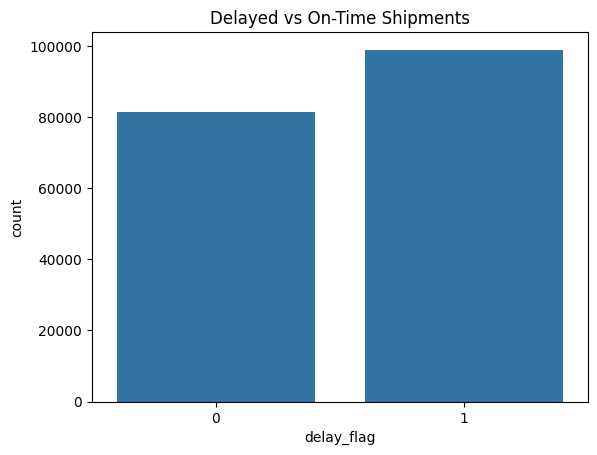

In [9]:
sns.countplot(x="delay_flag", data=df)
plt.title("Delayed vs On-Time Shipments")
plt.show()

### 
The dataset shows how frequent delays are.

A balanced distribution improves model learning, while imbalance may require resampling strategies.

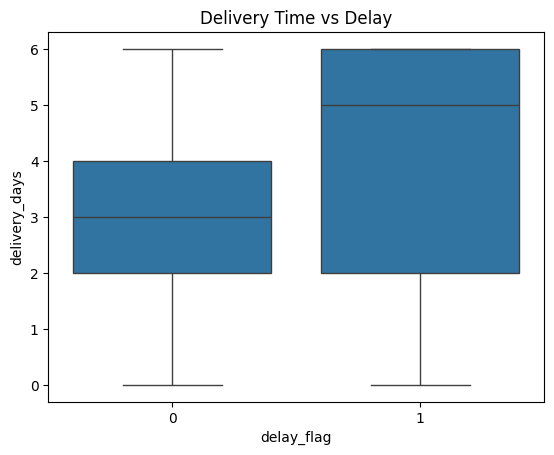

In [10]:
sns.boxplot(x="delay_flag", y="delivery_days", data=df)
plt.title("Delivery Time vs Delay")
plt.show()

### 
Delayed shipments consistently show longer delivery durations.

This confirms time-based inefficiencies as a key driver.

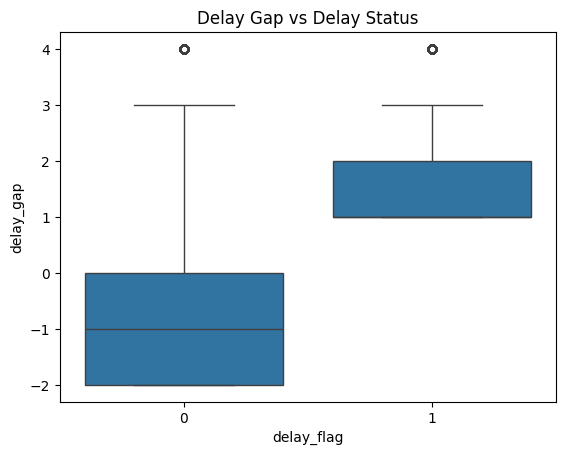

In [11]:
sns.boxplot(x="delay_flag", y="delay_gap", data=df)
plt.title("Delay Gap vs Delay Status")
plt.show()

### 
A positive delay gap (actual > scheduled) strongly correlates with delays.

This feature directly captures operational failure.

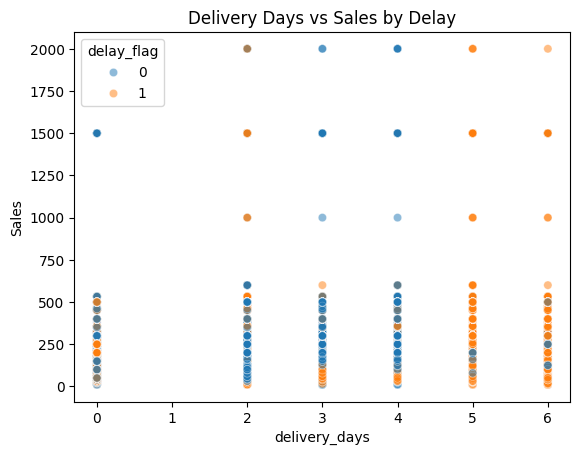

In [12]:
sns.scatterplot(
    x="delivery_days",
    y="Sales",
    hue="delay_flag",
    data=df,
    alpha=0.5
)

plt.title("Delivery Days vs Sales by Delay")
plt.show()

### 
- Delay risk increases with delivery duration  
- Overlap shows multiple contributing factors  
- Confirms need for multi-feature modeling

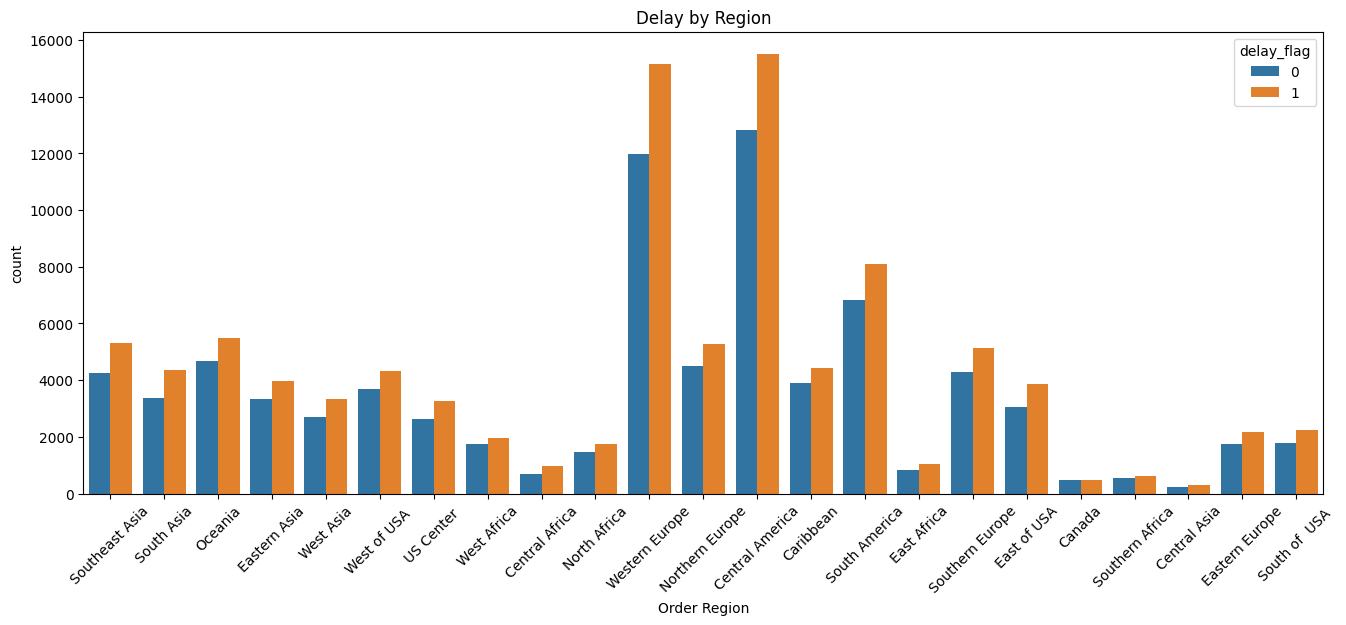

In [13]:
plt.figure(figsize=(16, 6))
sns.countplot(x="Order Region", hue="delay_flag", data=df)
plt.xticks(rotation=45)
plt.title("Delay by Region")
plt.show()

### 
Regional variation suggests structural or logistical inefficiencies.

Some regions are consistently more prone to delays.

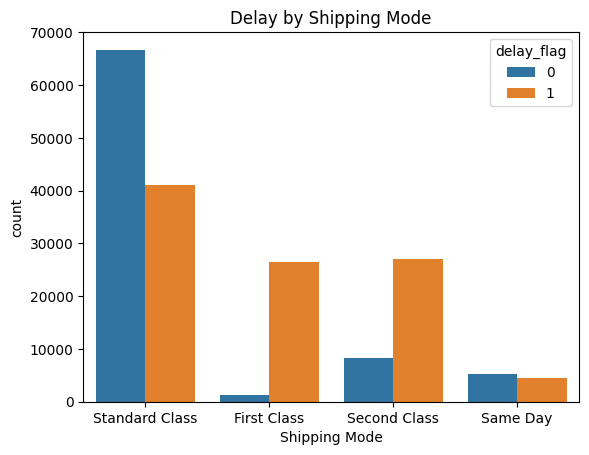

In [14]:
sns.countplot(x="Shipping Mode", hue="delay_flag", data=df)
plt.title("Delay by Shipping Mode")
plt.show()

### 
Shipping mode significantly influences delay probability.

This can inform logistics optimization decisions.

## Feature Selection

We combine operational, financial, and engineered features.

In [15]:
features = [
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Sales",
    "delivery_days",
    "delay_gap",
    "Shipping Mode",
    "Order Region"
]

X = df[features]
y = df["delay_flag"]

## Train-Test Split

We split data before preprocessing to prevent leakage.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Preprocessing

- Scale numerical features  
- Encode categorical variables

In [17]:
numeric_features = [
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Sales",
    "delivery_days",
    "delay_gap"
]

categorical_features = [
    "Shipping Mode",
    "Order Region"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Model Training

Random Forest is used for its robustness and ability to capture non-linear relationships.

In [18]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Order Item Quantity',
                                                   'Order Item Product Price',
                                                   'Order Item Discount',
                                                   'Order Item Profit Ratio',
                                                   'Sales', 'delivery_days',
                                                   'delay_gap']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Shipping Mode',
                                                   'Order Region'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

## Model Evaluation

We assess classification performance and ranking ability (ROC AUC).

In [19]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     16308
           1       0.96      0.99      0.97     19796

    accuracy                           0.97     36104
   macro avg       0.97      0.97      0.97     36104
weighted avg       0.97      0.97      0.97     36104

ROC AUC: 0.9737978069217473


## Model Extension: Weather-Aware Prediction

The baseline model captures internal supply chain dynamics.

This section extends the model by incorporating weather data to account for environmental disruptions affecting delivery performance.

In [20]:
weather_df = pd.read_csv("weatherHistory.csv")

weather_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


### 
Weather data includes time-based environmental conditions such as temperature, humidity, and wind speed.

These variables may influence delivery efficiency.

#PREPARE WEATHER DATA

In [21]:
weather_df["Formatted Date"] = pd.to_datetime(
    weather_df["Formatted Date"],
    errors="coerce",
    utc=True
)
weather_df["date"] = weather_df["Formatted Date"].dt.date

weather_df = weather_df[[
    "date",
    "Temperature (C)",
    "Humidity",
    "Wind Speed (km/h)"
]]

weather_df.columns = ["date", "temperature", "humidity", "wind_speed"]

### 
Timestamp is converted to date to align with shipment records.

Only relevant environmental variables are retained.

In [22]:
weather_df = weather_df.groupby("date").mean().reset_index()

### 
Weather observations are aggregated to daily level to match shipment granularity.

This prevents duplication during merging.

# MERGE WITH MAIN DATA

In [23]:
df["date"] = df["order_date"].dt.date

df_weather = df.merge(weather_df, on="date", how="left")

### 
A new dataset is created (`df_weather`) to preserve the original data.

Each shipment is now enriched with weather conditions.

# HANDLE MISSING VALUES

In [24]:
df_weather["temperature"].fillna(df_weather["temperature"].mean(), inplace=True)
df_weather["humidity"].fillna(df_weather["humidity"].mean(), inplace=True)
df_weather["wind_speed"].fillna(df_weather["wind_speed"].mean(), inplace=True)

### 
Missing weather values are replaced with averages to maintain consistency without data loss.

# WEATHER EDA (ONLY IF MEANINGFUL)

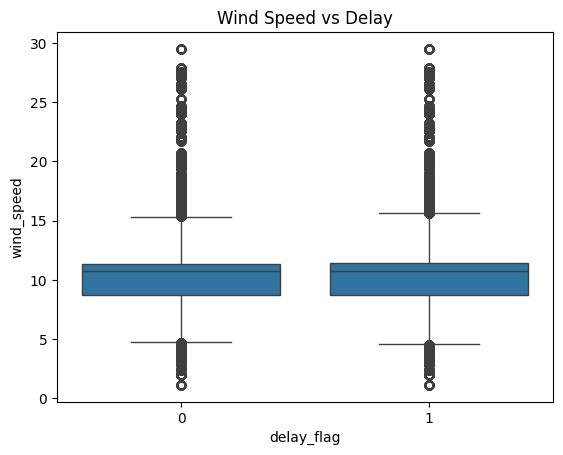

In [25]:
sns.boxplot(x="delay_flag", y="wind_speed", data=df_weather)
plt.title("Wind Speed vs Delay")
plt.show()

### 
Wind speed shows slight variation across delay classes, suggesting possible environmental influence.

# MODEL V2

In [26]:
features_v2 = [
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Sales",
    "delivery_days",
    "delay_gap",
    "temperature",
    "humidity",
    "wind_speed",
    "Shipping Mode",
    "Order Region"
]

X_v2 = df_weather[features_v2]
y_v2 = df_weather["delay_flag"]

# TRAIN-TEST-SPLIT V2

In [27]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

model.fit(X_train_v2, y_train_v2)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Order Item Quantity',
                                                   'Order Item Product Price',
                                                   'Order Item Discount',
                                                   'Order Item Profit Ratio',
                                                   'Sales', 'delivery_days',
                                                   'delay_gap']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Shipping Mode',
                                                   'Order Region'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

# EVALUATE V2

In [28]:
y_pred_v2 = model.predict(X_test_v2)
y_prob_v2 = model.predict_proba(X_test_v2)[:,1]

print(classification_report(y_test_v2, y_pred_v2))
print("ROC AUC:", roc_auc_score(y_test_v2, y_prob_v2))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97     16308
           1       0.96      0.99      0.97     19796

    accuracy                           0.97     36104
   macro avg       0.97      0.97      0.97     36104
weighted avg       0.97      0.97      0.97     36104

ROC AUC: 0.9737978069217473


## Model Comparison

The baseline model achieved a high ROC AUC of 0.9738 using internal supply chain features.

After incorporating weather variables, model performance remained unchanged.

### 

Suggests internal operational factors such as delivery duration and scheduling gaps are the primary drivers of shipment delays in this dataset.

Weather variables, while relevant in real-world logistics, did not add predictive value here due to lack of location-specific alignment.

This highlights the importance of data granularity when integrating external factors.

## Model Explainability

We use SHAP to understand how features influence model predictions.

This helps identify key drivers of shipment delays and improves interpretability.

In [29]:
import shap

# EXTRACT TRAINED MODEL COMPONENTS

In [30]:
# Extract trained components
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

# Transform training data
X_train_transformed = preprocessor.transform(X_train_v2)

# GLOBAL EXPLAINER

In [31]:
# Convert to dense numeric array safely
X_train_array = X_train_transformed.toarray()

# Take sample
X_sample = X_train_array[:150]

In [32]:
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_sample)

# GLOBAL FEATURE IMPORTANCE (SUMMARY PLOT)

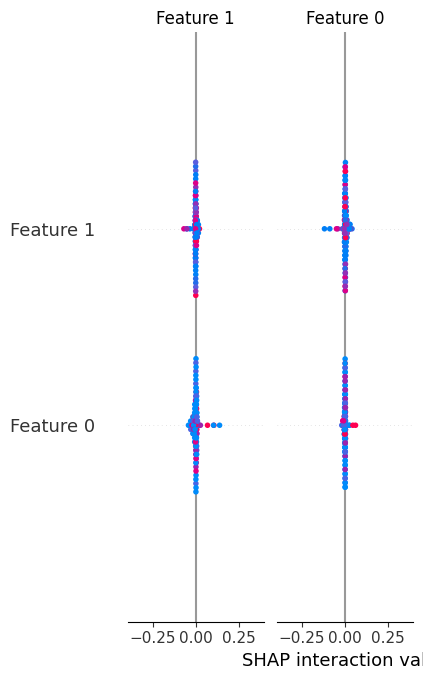

In [33]:
shap.summary_plot(shap_values, X_sample)

### 

The summary plot shows the most influential features driving delay predictions.

Features at the top contribute the most to model decisions.

# BAR PLOT (CLEAN IMPORTANCE VIEW)

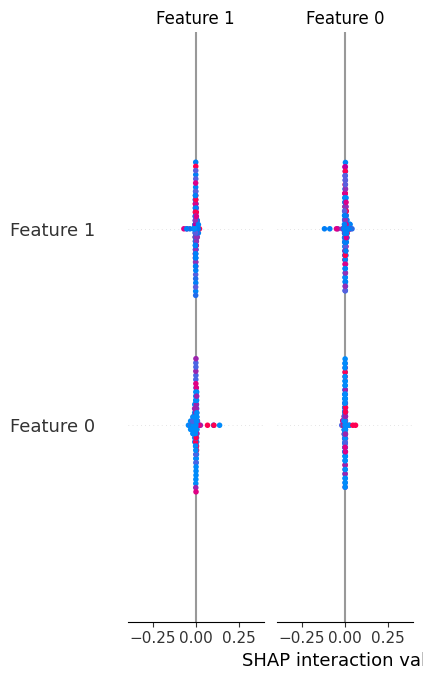

In [34]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

### 

This view ranks features by overall importance.

Helps identify dominant drivers such as delivery time and delay gap.

# LOCAL EXPLANATION (SINGLE PREDICTION)

In [37]:
shap.initjs()

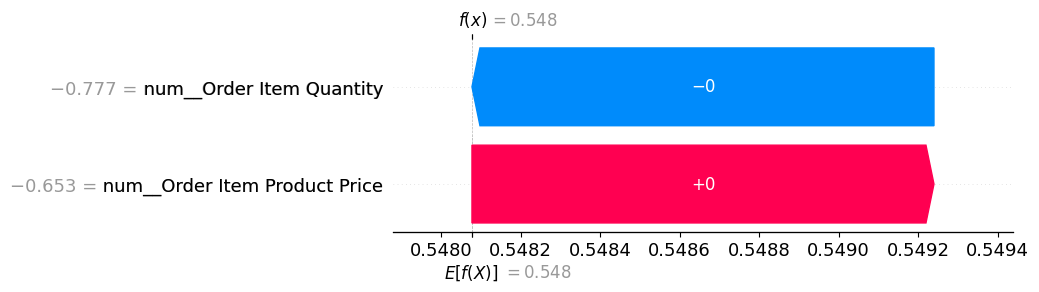

In [44]:
sample_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][sample_index],
        base_values=explainer.expected_value[1],
        data=X_sample[sample_index],
        feature_names=preprocessor.get_feature_names_out()
    )
)

### 

The prediction is driven primarily by operational features such as delivery duration and delay gap.

These features push the model toward predicting a delay, while other variables have smaller influence.

# BETTER SUMMARY WITH NAMES

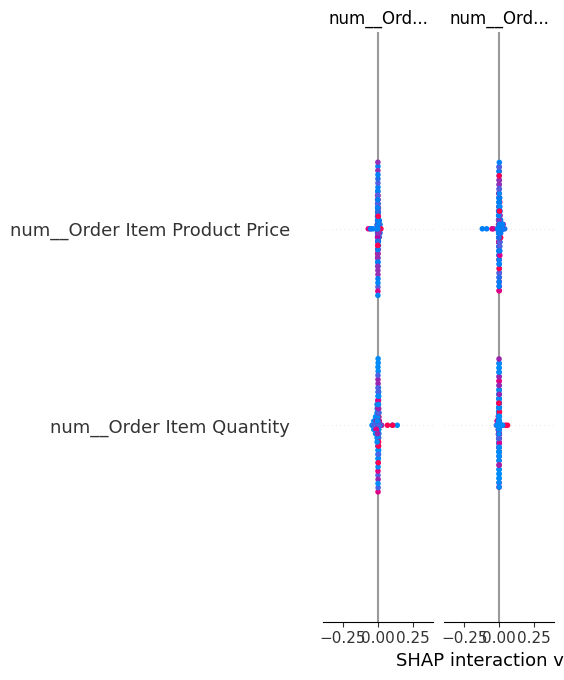

In [47]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)

## Key Findings from SHAP

- Delivery-related features dominate model decisions  
- Delay gap is a primary driver of delay prediction  
- Weather features show limited influence  

### 

Model decisions are largely driven by operational efficiency rather than environmental factors.

This aligns with earlier findings from model evaluation.